# 01 — Exploration: sanity-checking the synthetic generator

**Purpose.** Before any modelling, confirm that `data/raw/shipments.csv` contains
*causally-linked* shipment data rather than four columns of independent noise
wearing delay-shaped labels.

A generator that draws each stage delay independently would produce histograms
and summary statistics that look perfectly plausible in isolation, yet contain
no propagation to learn — every model would then top out near the noise floor
and no explanation of "which upstream stage caused this" could ever be honest.
So the checks below are deliberately about *relationships*, not marginals:

1. Load the raw shipments.
2. Summary statistics for every stage delay and `total_delay_hours`.
3. Histograms of `total_delay_hours` and each stage delay.
4. `port_delay_hours` vs `departure_delay_hours` — the propagation check. An
   early-stage delay should visibly push the next stage's delay up.
5. Class balance for `is_delayed`.
6. Correlation of the operational drivers (congestion, weather, customs
   complexity, document readiness) against `total_delay_hours`.

What "passing" looks like: a clearly positive departure→port relationship, and
driver correlations that are non-trivial and carry the causally sensible sign —
positive for the three severity scales, **negative** for `document_readiness`,
since better paperwork should shorten a shipment rather than lengthen it.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)


def find_repo_root(start: Path | None = None) -> Path:
    """Locate the project root by walking upward until a `data/raw` dir appears.

    Jupyter sets the kernel's working directory to the notebook's own folder,
    but the same notebook is often run from the repo root instead. Resolving the
    root by structure rather than a hardcoded "../" keeps the load cell correct
    either way, which matters because every later path is derived from it.
    """
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "data" / "raw").is_dir():
            return candidate
    raise FileNotFoundError(f"No 'data/raw' directory found at or above {here}")


REPO_ROOT = find_repo_root()
RAW_CSV = REPO_ROOT / "data" / "raw" / "shipments.csv"

DATETIME_COLS = [
    "scheduled_departure",
    "scheduled_port_arrival",
    "scheduled_customs_clearance",
    "scheduled_delivery",
    "actual_departure",
    "actual_port_arrival",
    "actual_customs_clearance",
    "actual_delivery",
]

# Read the header alone first: parse_dates raises on a column that is absent,
# and this notebook should degrade gracefully if the generator's schema shifts
# rather than dying on the load cell.
header = pd.read_csv(RAW_CSV, nrows=0).columns
df = pd.read_csv(RAW_CSV, parse_dates=[c for c in DATETIME_COLS if c in header])

print(f"Loaded {RAW_CSV.relative_to(REPO_ROOT).as_posix()}")
print(f"  {df.shape[0]} rows x {df.shape[1]} columns")


Loaded data/raw/shipments.csv
  300 rows x 28 columns


## 2. Summary statistics — stage delays and total delay

In [2]:
STAGE_DELAY_COLS = [
    "departure_delay_hours",
    "port_delay_hours",
    "customs_delay_hours",
    "inland_delay_hours",
]
DELAY_COLS = STAGE_DELAY_COLS + ["total_delay_hours"]

print(df[DELAY_COLS].describe().round(2).to_string())


       departure_delay_hours  port_delay_hours  customs_delay_hours  inland_delay_hours  total_delay_hours
count                 300.00            260.00               300.00              300.00             300.00
mean                    0.65              1.31                 1.82                1.78               5.54
std                     0.42              0.81                 0.89                0.87               2.20
min                     0.00              0.00                 0.00                0.00               1.21
25%                     0.31              0.65                 1.17                1.16               4.00
50%                     0.67              1.16                 1.70                1.70               5.30
75%                     0.99              1.90                 2.48                2.40               7.02
max                     1.75              3.31                 4.50                4.21              11.58


## 3. Distributions of total delay and each stage delay

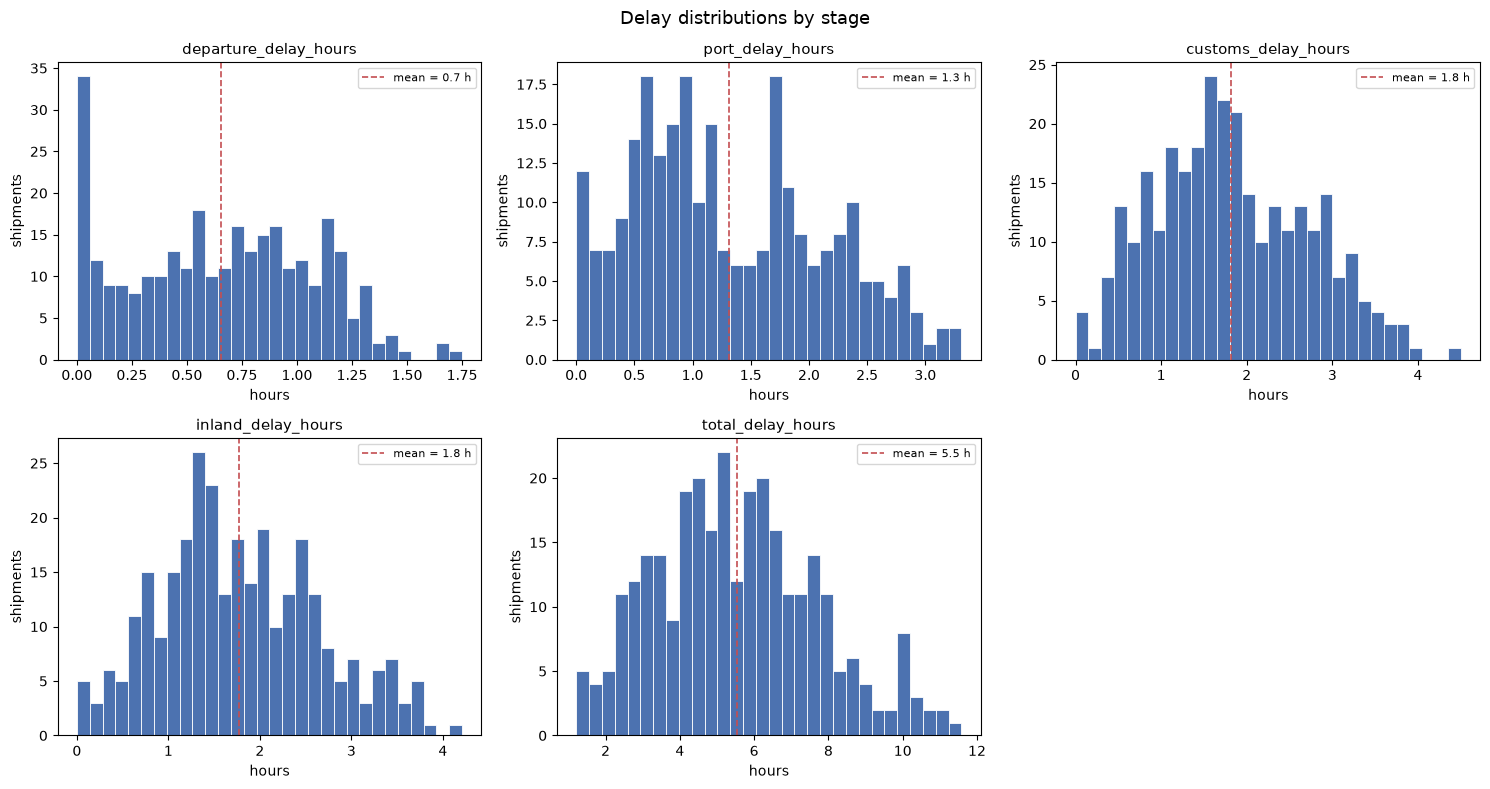

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, col in zip(axes, DELAY_COLS):
    values = df[col].dropna()
    ax.hist(values, bins=30, color="#4C72B0", edgecolor="white", linewidth=0.6)
    ax.axvline(
        values.mean(),
        color="#C44E52",
        linestyle="--",
        linewidth=1.2,
        label=f"mean = {values.mean():.1f} h",
    )
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("hours")
    ax.set_ylabel("shipments")
    ax.legend(fontsize=8)

# Five delay columns in a 2x3 grid leave one panel spare.
for spare in axes[len(DELAY_COLS):]:
    spare.set_visible(False)

fig.suptitle("Delay distributions by stage", fontsize=13)
fig.tight_layout()
plt.show()


## 4. Propagation check — does departure delay push port delay up?

This is the load-bearing plot of the notebook. If the generator wired the stages
together, leaving late should still be late on arrival at port; if it drew each
stage independently, this scatter is a shapeless cloud with `r` near zero.


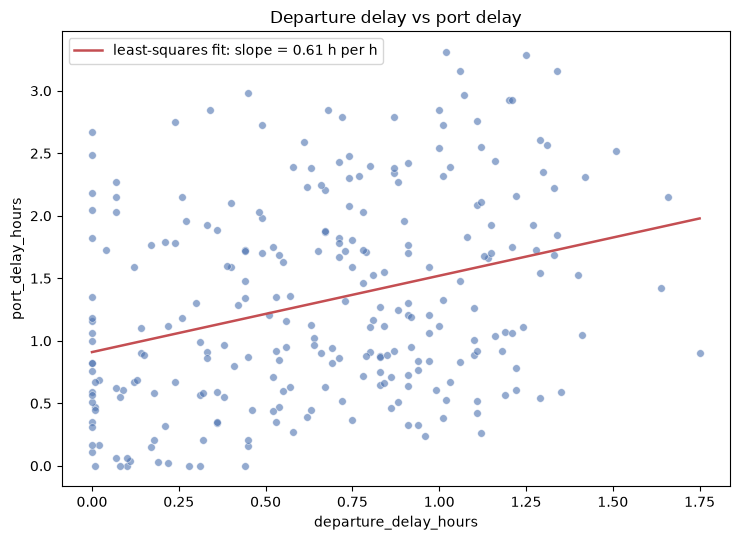

n (both observed)      = 260
Pearson r              = +0.314
Spearman rho           = +0.306
OLS slope (hours/hour) = +0.611


In [4]:
pair = df[["departure_delay_hours", "port_delay_hours"]].dropna()
x = pair["departure_delay_hours"]
y = pair["port_delay_hours"]

pearson = x.corr(y)
spearman = x.corr(y, method="spearman")

# Least-squares slope, reported alongside r: a correlation says the two move
# together, the slope says how many hours of port delay one hour of departure
# delay actually buys -- which is the quantity propagation is about.
slope, intercept = np.polyfit(x, y, 1)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.scatter(x, y, alpha=0.6, s=30, color="#4C72B0", edgecolor="white", linewidth=0.5)
grid = np.linspace(x.min(), x.max(), 100)
ax.plot(
    grid,
    slope * grid + intercept,
    color="#C44E52",
    linewidth=1.8,
    label=f"least-squares fit: slope = {slope:.2f} h per h",
)
ax.set_xlabel("departure_delay_hours")
ax.set_ylabel("port_delay_hours")
ax.set_title("Departure delay vs port delay")
ax.legend()
fig.tight_layout()
plt.show()

print(f"n (both observed)      = {len(pair)}")
print(f"Pearson r              = {pearson:+.3f}")
print(f"Spearman rho           = {spearman:+.3f}")
print(f"OLS slope (hours/hour) = {slope:+.3f}")


## 5. Class balance — `is_delayed`

In [5]:
is_delayed = df["is_delayed"]

# A bool column normally survives the CSV round-trip as dtype bool, but another
# writer (or a regenerated file) can hand back the strings "True"/"False" --
# and every non-empty string is truthy, so an unguarded .sum() would silently
# report a 100% delay rate. Normalise before counting.
if not pd.api.types.is_bool_dtype(is_delayed):
    is_delayed = (
        is_delayed.astype(str)
        .str.strip()
        .str.lower()
        .map({"true": True, "false": False, "1": True, "0": False})
        .astype("boolean")
    )

n_total = int(is_delayed.notna().sum())
n_delayed = int(is_delayed.sum())
n_ontime = n_total - n_delayed

print(f"is_delayed == True  : {n_delayed:4d} / {n_total}  ({n_delayed / n_total:6.1%})")
print(f"is_delayed == False : {n_ontime:4d} / {n_total}  ({n_ontime / n_total:6.1%})")


is_delayed == True  :  120 / 300  ( 40.0%)
is_delayed == False :  180 / 300  ( 60.0%)


## 6. Operational drivers vs total delay

In [6]:
DRIVER_COLS = [
    "port_congestion",
    "weather_severity",
    "customs_complexity",
    "document_readiness",
]

corr = df[DRIVER_COLS + ["total_delay_hours"]].corr(numeric_only=True)
print(corr.round(3).to_string())
print()

# Sign matters more than magnitude here. The three severity scales (0-3) should
# be positively correlated with delay; document_readiness is a 0-1 "paperwork is
# in order" score, so a NEGATIVE correlation is the causally correct outcome --
# a positive one would mean the generator wired that driver backwards.
against_total = corr["total_delay_hours"].drop("total_delay_hours")
ranked = against_total.reindex(against_total.abs().sort_values(ascending=False).index)

print("Correlation with total_delay_hours, strongest absolute first:")
for name, value in ranked.items():
    expected = "negative" if name == "document_readiness" else "positive"
    actual = "negative" if value < 0 else "positive"
    verdict = "as expected" if actual == expected else "UNEXPECTED SIGN"
    print(f"  {name:22s} {value:+.3f}   ({verdict})")


                    port_congestion  weather_severity  customs_complexity  document_readiness  total_delay_hours
port_congestion               1.000             0.084              -0.022               0.059              0.590
weather_severity              0.084             1.000              -0.053              -0.004              0.296
customs_complexity           -0.022            -0.053               1.000               0.072              0.475
document_readiness            0.059            -0.004               0.072               1.000             -0.301
total_delay_hours             0.590             0.296               0.475              -0.301              1.000

Correlation with total_delay_hours, strongest absolute first:
  port_congestion        +0.590   (as expected)
  customs_complexity     +0.475   (as expected)
  document_readiness     -0.301   (as expected)
  weather_severity       +0.296   (as expected)
